### Corner finding and dimension estimate workbook

Start with the corner finding with 1 dimensional underlying spaces

In [74]:
# Packages - we will not need all of these

import numpy as np
from numpy import random
import plotly.graph_objects as go
from sympy.matrices.normalforms import smith_normal_form
import itertools
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import re
#import numpy as np
from sklearn.decomposition import PCA
from collections import Counter
from scipy import stats
#from phonemizer import phonemize
#from phonemizer.backend.espeak import EspeakBackend
import os
import jellyfish
#from rapidfuzz.distance import Levenshtein
#from metaphone import doublemetaphone
from ripser import ripser
from persim import plot_diagrams

In [116]:
# Some helpful functions

pca = PCA(n_components=1)

def assoc_tangents(points, thresh):

    sample_size = len(points)

    D = squareform(pdist(points))

    graph = [[] for _ in range(sample_size)]

    for i in range(sample_size):
        for j in range(sample_size):
            if i != j and D[i, j] <= thresh:
                graph[i].append(j)
    #connected = (D <= thresh).astype(int)
    direction_dict = {}
    for i in range(sample_size):
        p = points[i]
        #dists = np.linalg.norm(points - points[i], axis=1)
        within_tol = points[D[i] <= thresh]

        shifted = within_tol - within_tol.mean(axis=0)
        pca.fit(shifted)

        v = pca.components_[0]   # unit vector

        dists = D[i].copy()
        dists[i] = np.inf                  # don't choose itself
        j = np.argmin(dists)               # nearest neighbour
        displacement = points[j] - p       # vector toward NN

        if np.dot(v, displacement) < 0:
            v = -v

        direction_dict[tuple(p)] = v

        #### Now we globally order tangents based on some starting point, and using the nearest threshold region in the same direction,
        #### continuing this forward until we have all points oriented for that connected component, and 

    visited = []
    oriented = {}

    for k in range(sample_size):
        if k not in visited: # Start a new chain for each connected component from the graph
            finished = False
            tangent = direction_dict[tuple(points[k])].copy() # Orienting tangent direction
            oriented[tuple(points[k])] = tangent # Add to the dictionary of oriented tangents
            visited.append(k) # Don't wanna add it twice - keep track of where we've been
            to_orient = graph[k] # adjacent vertices
            paired = []
            for j in to_orient:
                paired.append([j,k]) # create pairs where first is to be oriented compared to second
            
            
            while not finished:
                new_pairs = [] # Set of pairs for the next iteration (depth)
                check = False # When we are at max "depth" i.e. no more connected elements to be oriented, this will remain false
                for pair in paired:
                    if pair[0] not in visited: # again, if we have already oriented, no orientation needed
                        check = True
                        comp_tangent = direction_dict[tuple(points[pair[0]])].copy()
                        if np.dot(oriented[tuple(points[pair[1]])], comp_tangent) < 0:
                            comp_tangent = -comp_tangent
                        oriented[tuple(points[pair[0]])] = comp_tangent
                        visited.append(pair[0])
                    for conns in graph[pair[0]]:
                        if conns not in visited:
                            new_pairs.append([conns,pair[0]])
                paired = new_pairs
                if not check:
                    finished = True
    
    return oriented#direction_dict

data = np.zeros((5,2))
data[0,0] = 1
data[1,0] = 0.2
data[2,1] = 0.3
data[3,0] = 0.5



def plot_tangents(dict):
    '''
    dict is a dictionary where keys are points (as coordinates) as strings and they point to an array corresponding to the tangent vector
    '''
    plt.figure(figsize=(6,6))

    # DO NOT DELETE THIS COMMENT
    #fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig, ax1 = plt.subplots()
    
    for entry in dict:
        vector = dict[entry]
        point = np.array(entry)
        ax1.scatter(point[0], point[1], s=20, color='black')
        ax1.quiver(
            point[0], point[1],     # starting point
            vector[0], vector[1],     # direction vector
            #angles='xy',
            #scale_units='xy',
            #scale=1/scale,  # controls arrow length
            color='red',
            width=0.005
        )
        # IF WE WANT TO INCLUDE VECTORS ON THE CIRCLE UNCOMMENT
        #ax2.scatter(vector[0], vector[1], s=20, color='black')

    plt.show()

#plot_tangents(assoc_tangents(u_shape, 0.3))
#pca = PCA(n_components=2)
#pca.fit(matrix)

def Most_Common(lst):
    considered = []
    max_occurances = 0
    for item in lst:
        if item not in considered:
            counter = 0
            for item2 in lst:
                if item2 == item:
                    counter += 1
            if counter > max_occurances:
                max_occurances = counter
                max_item = item
            considered.append(item)
    return max_item



def corner_spotter(matrix):
    """"
    - We start by finding an estimate for the topology, using a VR complex (FOR NOW) at various values of epsilon on the data matrix
    - Next, we construct the tangent field. Note that this currently works only in two dimensions
    - The tangent is added as a feature to each data point, and the homology is recomputed
    - Changes in betti number indicate that a corner (in some dimension) is present
    - We currently use epsilon from twice the minimum distance to 1/5 the maximum distance between points
    """
    min_dist = 2*np.min(pdist(matrix))
    max_dist = 0.3*np.max(pdist(matrix))

    inc = (max_dist - min_dist)/5


    betti_seq = []
    for i in range(6):
        eps = min_dist+i*inc
        print("Epsilon value is", eps)
        vr_complex = vr(matrix, eps)
        hom_groups = homology_mats(create_mats(vr_complex, "real"))
        while hom_groups and hom_groups[-1]==0:
            hom_groups.pop()
        betti_seq.append(list(hom_groups))
        print("betti groups are", hom_groups)
    most_common = Most_Common(list(betti_seq))
    print("most common occurance is", most_common)

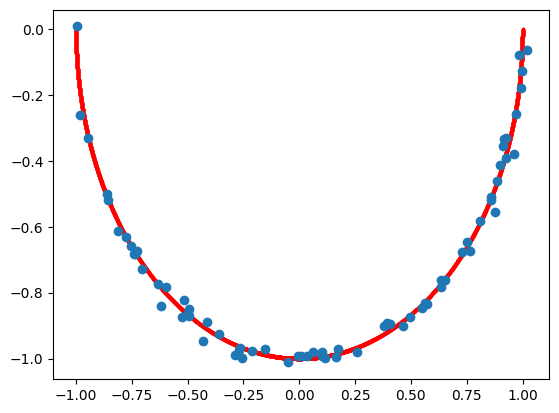

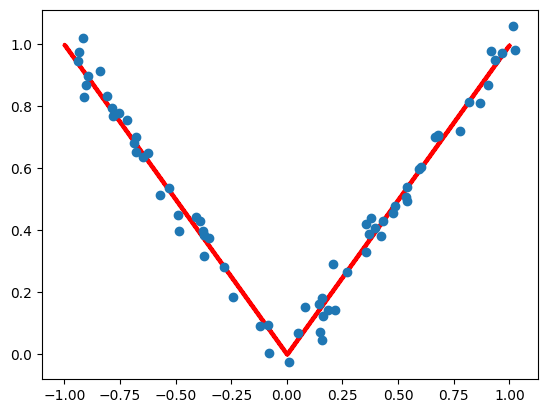

In [118]:
# We define two shapes to contrast

rng = np.random.default_rng(42) # for reproduceability

rand_val = rng.uniform(0.25,0.75)
x = np.sin(2*np.pi*rand_val) + rng.normal(loc=0,scale=0.05)
y = np.cos(2*np.pi*rand_val) + rng.normal(loc=0,scale=0.05)
u_shape = np.array([x,y])
for i in range(69):
    rand_val = rng.uniform(0.25,0.75)
    x = np.sin(2*np.pi*rand_val) + rng.normal(loc=0,scale=0.02)
    y = np.cos(2*np.pi*rand_val) + rng.normal(loc=0,scale=0.02)
    coord = np.array([x,y])
    u_shape = np.vstack((u_shape,coord)) 

true_u = np.array([0,-1])

for i in range(10000):
    val = 0.25+i*0.00005
    x = np.sin(2*np.pi*val)
    y = np.cos(2*np.pi*val)
    coord = np.array([x,y])
    true_u = np.vstack((true_u,coord)) 
# for i in range(50):
#     rand_val = np.random.uniform(-1,1)
#     y = 0#np.random.normal(loc=0,scale=0.005)
#     x = rand_val #+ np.random.normal(loc=0,scale=0.005)
#     coord = np.array([x,y])
#     u_shape = np.vstack((u_shape,coord))  




rand_val = rng.uniform(-1,1)
x = rand_val
y = abs(x)
v_shape = np.array([x,y])
for i in range(69):
    rand_val = rng.uniform(-1,1)
    x = rand_val + rng.normal(loc=0,scale=0.05)
    y = abs(x) + rng.normal(loc=0,scale=0.05)
    coord = np.array([x,y])
    v_shape = np.vstack((v_shape,coord))

true_v = np.array([0,0])

for i in range(10000):
    val = -1+i*0.0002
    x = val
    y = abs(val)
    coord = np.array([x,y])
    true_v = np.vstack((true_v,coord))


x_u = u_shape[:,0]
y_u = u_shape[:,1]
plt.scatter(true_u[:,0], true_u[:,1], color="red", s=2)
plt.scatter(x_u,y_u)
plt.show()

x_v = v_shape[:,0]
y_v = v_shape[:,1]

plt.scatter(true_v[:,0], true_v[:,1], color="red", s=2)
plt.scatter(x_v,y_v)
plt.show()

<Figure size 600x600 with 0 Axes>

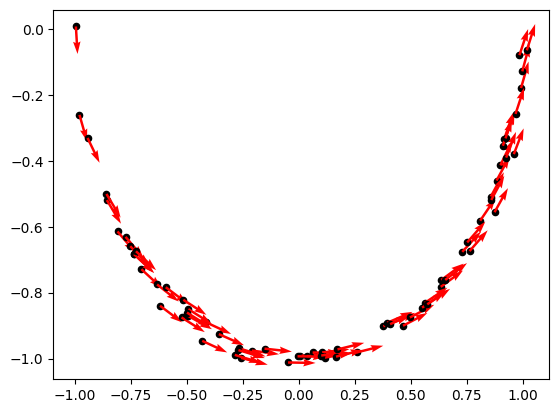

<Figure size 600x600 with 0 Axes>

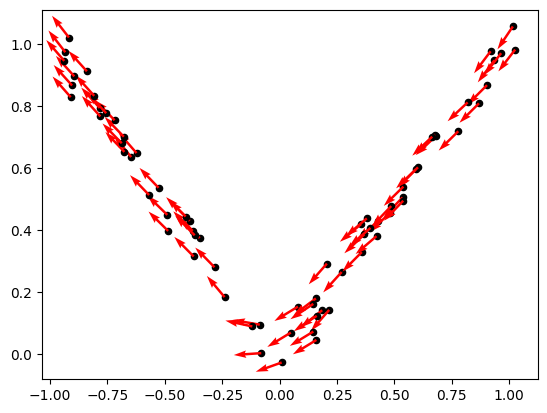

In [117]:
# Now we plot the associated tangents at the points

plot_tangents(assoc_tangents(u_shape,0.3))
plot_tangents(assoc_tangents(v_shape,0.3))

In [100]:
def add_tangent_angle(dict):
    '''
    dict is a dictionary where keys are points (as coordinates) as strings and they point to an array corresponding to the tangent vector
    '''
    points_3d = []
    for entry in dict:
        vector = dict[entry]
        point = np.array(entry)
        angle = np.arctan2(vector[1],vector[0])

        point_enhanced = np.append(point, angle)

        points_3d.append(point_enhanced)
    
    return np.array(points_3d)


def plot_points_3d(points):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.scatter(points[:,0], points[:,1], points[:,2])

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel(r"$\theta$")
    ax.view_init(elev=30, azim=280)

    plt.show()

def plot_points_3d_interactive(points):

    fig = go.Figure(data=[go.Scatter3d(
        x=points[:,0],
        y=points[:,1],
        z=points[:,2],
        mode='markers',
        marker=dict(size=4)
    )])

    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title=f"$\theta$"
        )
    )

    fig.show()
    

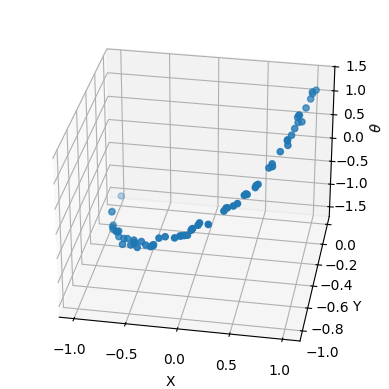

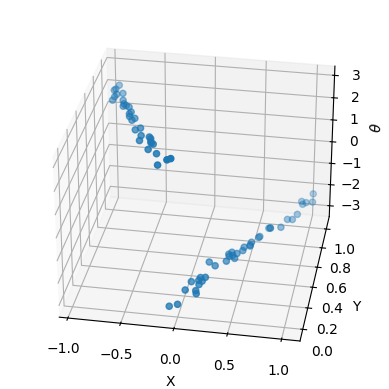

In [101]:
plot_points_3d(add_tangent_angle(assoc_tangents(u_shape,0.3)))

plot_points_3d(add_tangent_angle(assoc_tangents(v_shape,0.3)))

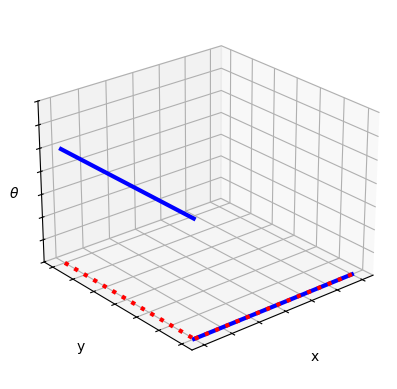

In [42]:
# Some figure for the presentation

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# --- V shape in the xy plane ---
x1 = np.linspace(3, 0, 50)
y1 = np.zeros_like(x1)
z1 = np.zeros_like(x1)

x2 = y1#np.linspace(0, 2, 50)
y2 = x1
z2 = np.zeros_like(x2)


# --- horizontal line above left arm ---
xL = np.linspace(3, 0, 50)
yL = y1
zL = np.ones_like(xL) * 0

ax.plot(xL, yL, zL, linewidth=3, color="blue")

# --- horizontal line above right arm ---
xR = y1
yR = x1
zR = np.ones_like(xR) * 0.5

ax.plot(xR, yR, zR, linewidth=3, color="blue")

ax.plot(x1, y1, z1, linewidth=3, color="red", linestyle=":")
ax.plot(x2, y2, z2, linewidth=3, color="red", linestyle=":")

# labels
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$\theta$', labelpad=50, rotation=180)

ax.view_init(elev=25, azim=230)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_zlim(0,0.7)
ax.text(-0.2, 4.1, 0.2, r'$\theta$', fontsize=10)


plt.show()

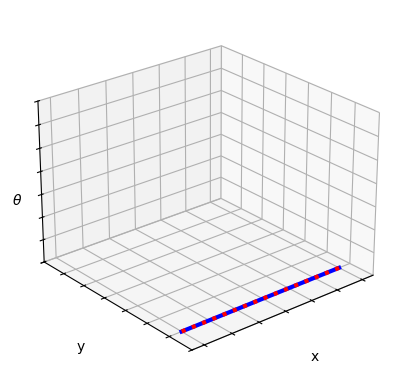

In [73]:
# Some figure for the presentation

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# --- line in the xy plane ---
x1 = np.linspace(3, -3, 50)
y1 = np.zeros_like(x1)
z1 = np.zeros_like(x1)



# --- horizontal line above left arm ---
xL = x1
yL = y1
zL = np.ones_like(xL) * 0

ax.plot(xL, yL, zL, linewidth=3, color="blue")



ax.plot(x1, y1, z1, linewidth=3, color="red", linestyle=":")

# labels
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$\theta$', labelpad=50, rotation=180)

ax.view_init(elev=25, azim=230)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_zlim(0,0.7)
ax.set_ylim(-0.5,3)
ax.text(-4.5, 3, 0.3, r'$\theta$', fontsize=10)
#ax.text(-0.5, 1.5, 0.2, "y", fontsize=10)
#ax.plot([0,0], [-0.5,3], [0,0], color="black", linewidth=1)
#ax.plot([0,0], [3,3], [0,0.7], color="black", linewidth=1)
#ax.yaxis.line.set_color((0,0,0,0))
#ax.zaxis.line.set_color((0,0,0,0))


plt.show()